# Why N sources on a circle draw an N-petal flower (and when that breaks)

**The question:** in `ripple_interference.ipynb`, N synchronized point sources evenly spaced on a circle always converged into an N-fold symmetric shape -- a pentagon of sources always drew a 5-petal flower, never a 4 or 6. Is that exact, or a coincidence of the specific parameters we happened to pick? And what actually is the role of the sources' coherence (resonance length) in all this -- does it control how sharp the pattern is, as classical interferometry would suggest?

**Answer, worked out below:** the N-fold shape is exact -- a direct consequence of the source arrangement's discrete rotational symmetry, true for *any* per-source pulse shape, resonance length, or envelope. That part has nothing to do with coherence. What resonance length actually controls is something narrower and more interesting: how *fragile* the pattern is to small imperfections in the source placement -- and it turns out to help against some kinds of imperfection while actively hurting against others. My first guess (`resonance length limits how far the clean interference extends`) was wrong, and the numbers said so immediately -- that correction is most of what's actually in this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

WAVELENGTH = 1.5
C = 4.0
K = 2 * np.pi / WAVELENGTH
OMEGA = K * C
EDGE_WIDTH = 0.4

C_PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"]  # Okabe-Ito, fixed order

def field(X, Y, t, sources, resonance_length):
    """Same model as ripple_interference.ipynb: causal ahead, exponential ringdown behind."""
    Z = np.zeros_like(X)
    for sx, sy, t_start in sources:
        r = np.sqrt((X - sx) ** 2 + (Y - sy) ** 2)
        dt = t - t_start
        front = C * dt
        behind = front - r
        causal_gate = 0.5 * (1 + np.tanh(behind / EDGE_WIDTH))
        ringdown = np.exp(-np.clip(behind, 0, None) / resonance_length)
        amplitude = causal_gate * ringdown / np.sqrt(r + 0.3)
        Z += amplitude * np.cos(K * r - OMEGA * dt)
    return Z

def ring_of_sources(n, radius, t_start=0.0):
    return [(radius * np.cos(2 * np.pi * j / n), radius * np.sin(2 * np.pi * j / n), t_start) for j in range(n)]

R = 6.0
T_CONV = R / C  # every source's front reaches the center at this instant

## Deriving it: why the pattern can only have N-fold symmetry

**The free version (no calculation needed).** Rotate the whole picture by $2\pi/N$ about the center. Source $j$ lands exactly on source $j{+}1$'s old position, and since every source emits by the identical rule (same wavelength, same resonance length, same start time), the field is completely unchanged by this rotation -- the configuration has exact discrete rotational symmetry $C_N$. A function invariant under rotation by $2\pi/N$ can only contain angular Fourier components at multiples of $N$; anything else would not survive the rotation. This holds regardless of the radial envelope, the resonance length, the causal gate shape -- none of that machinery matters to this argument. It only used the *symmetry* of the source layout.

**The explicit version (worth doing once, because it's where the real machinery -- Bessel functions -- shows up and connects this to classical diffraction/array theory).** For a point $p=(\rho,\psi)$ near the center ($\rho \ll R$), the distance to source $j$ (at angle $\alpha_j = 2\pi j/N$) is

$$r_j = |p - R\hat u_j| \approx R - \rho\cos(\psi-\alpha_j)$$

For a continuous coherent source (drop the resonance/causal machinery for a moment -- pure monochromatic waves), summing all $N$ contributions:

$$Z(\rho,\psi,t) \propto \sum_{j=0}^{N-1} \cos\!\big(kR - \omega t - k\rho\cos(\psi-\alpha_j)\big)$$

Write this as $\text{Re}\big[e^{i(kR-\omega t)}\sum_j e^{-ik\rho\cos(\psi-\alpha_j)}\big]$ and expand each term with the **Jacobi-Anger identity** $e^{iz\cos\theta} = \sum_m i^m J_m(z) e^{im\theta}$:

$$\sum_{j=0}^{N-1} e^{-ik\rho\cos(\psi-\alpha_j)} = \sum_m i^m J_m(k\rho)\, e^{im\psi} \underbrace{\sum_{j=0}^{N-1} e^{-im\alpha_j}}_{=\,N \text{ if } N\mid m,\ \text{else } 0}$$

The inner sum is the discrete orthogonality of $N$-th roots of unity -- it vanishes unless $m$ is a multiple of $N$. So:

$$Z(\rho,\psi,t) \propto N\sum_{n=-\infty}^{\infty} i^{nN} J_{nN}(k\rho)\,\cos(nN\psi + \text{phase})$$

Only harmonics $m = 0, \pm N, \pm 2N,\dots$ survive. The leading $\psi$-dependent term ($n=\pm1$) oscillates at order $N$ -- that's the N petals. This is exactly the mathematics behind circular antenna arrays and N-slit diffraction gratings; nothing here is new physics. What we test below is what happens to it once the sources are pulsed and imperfectly placed, which is less commonly spelled out.

## Measuring "how N-fold" a pattern actually is

Sample the field on a circle of radius $\rho$ around the center, take its FFT with respect to the angle $\psi$, and define **purity** = (power at harmonics that are multiples of $N$) / (total non-constant power). The derivation predicts purity $=1$ exactly, for *any* resonance length, *any* $N$, as long as the source layout is exactly symmetric.

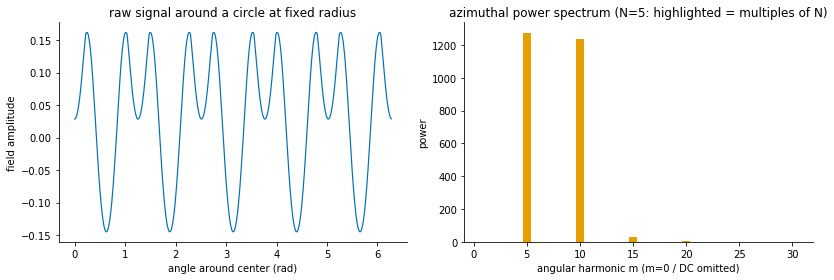

purity = 1.000000


In [2]:
N_PSI = 720

def purity(rho, t, sources, resonance_length, N):
    psi = np.linspace(0, 2 * np.pi, N_PSI, endpoint=False)
    X, Y = rho * np.cos(psi), rho * np.sin(psi)
    Z = field(X, Y, t, sources, resonance_length)
    power = np.abs(np.fft.rfft(Z)) ** 2
    ac_power = power[1:].sum()
    return power[N::N].sum() / ac_power if ac_power > 1e-30 else np.nan

# the smoking gun: raw signal has real higher-harmonic content (not just a bare cosine),
# but every bit of it sits exactly on multiples of N -- nothing in between
N, L, rho = 5, 0.5, 3.0
t_test = T_CONV + 2.3 / C
sources = ring_of_sources(N, R)
psi = np.linspace(0, 2 * np.pi, N_PSI, endpoint=False)
Z = field(rho * np.cos(psi), rho * np.sin(psi), t_test, sources, L)
power = np.abs(np.fft.rfft(Z)) ** 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(psi, Z, color=C_PALETTE[0], linewidth=1.2)
axes[0].set_xlabel("angle around center (rad)")
axes[0].set_ylabel("field amplitude")
axes[0].set_title("raw signal around a circle at fixed radius")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

harmonics = np.arange(1, len(power))  # drop m=0 (DC/mean level) -- it's not part of "purity" and dwarfs the scale
colors = [C_PALETTE[1] if m % N == 0 else "#BBBBBB" for m in harmonics]
axes[1].bar(harmonics[:30], power[1:31], color=colors[:30])
axes[1].set_xlabel("angular harmonic m (m=0 / DC omitted)")
axes[1].set_ylabel("power")
axes[1].set_title(f"azimuthal power spectrum (N={N}: highlighted = multiples of N)")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("purity_smoking_gun.png", dpi=110)
plt.show()

print(f"purity = {purity(rho, t_test, sources, L, N):.6f}")

## Does the exact symmetry hold for every N, and every resonance length?

The last notebook noticed N=3 *looked* different from N=4,5,6 (a pinwheel instead of a clean flower) and speculated this might be a genuine even/odd effect. The derivation above makes no such distinction -- it predicts purity 1 regardless of N's parity. Let's just check directly rather than speculate again.

In [3]:
print(f"{'N':>3} | {'L=0.4':>10} | {'L=2.0':>10} | {'L=8.0':>10}")
for N in range(3, 9):
    srcs = ring_of_sources(N, R)
    row = [purity(1.0, T_CONV + 2.3 / C, srcs, L, N) for L in (0.4, 2.0, 8.0)]
    print(f"{N:>3} | " + " | ".join(f"{v:>10.6f}" for v in row))

  N |      L=0.4 |      L=2.0 |      L=8.0
  3 |   1.000000 |   1.000000 |   1.000000
  4 |   1.000000 |   1.000000 |   1.000000
  5 |   1.000000 |   1.000000 |   1.000000
  6 |   1.000000 |   1.000000 |   1.000000
  7 |   1.000000 |   1.000000 |   1.000000
  8 |   1.000000 |   1.000000 |   1.000000


Purity is 1.000000 across the board -- N=3 is not special, and neither is resonance length. The earlier "pinwheel vs. flower" impression was just what a 3-petal shape looks like at low petal count, not a breakdown of the symmetry argument. Worth saying plainly: that was a real overreach on my part last time, and it took thirty seconds to check and rule out.

## So what does resonance length actually do?

If exact symmetry protects the pattern regardless of resonance length, my original hypothesis -- *short coherence length limits how far the clean interference extends* -- has nothing to act on. It's testably wrong, and the test takes one line. Let's run it before going further: hold the source layout exactly symmetric and sweep resonance length alone.

In [4]:
for L in [0.3, 1.0, 3.0, 9.0, 30.0]:
    srcs = ring_of_sources(5, R)
    print(f"L={L:5.1f}:  purity(rho=0.2)={purity(0.2, T_CONV+2.3/C, srcs, L, 5):.6f}   "
          f"purity(rho=2.0)={purity(2.0, T_CONV+2.3/C, srcs, L, 5):.6f}")

L=  0.3:  purity(rho=0.2)=1.000000   purity(rho=2.0)=1.000000
L=  1.0:  purity(rho=0.2)=1.000000   purity(rho=2.0)=1.000000
L=  3.0:  purity(rho=0.2)=1.000000   purity(rho=2.0)=1.000000
L=  9.0:  purity(rho=0.2)=1.000000   purity(rho=2.0)=1.000000
L= 30.0:  purity(rho=0.2)=1.000000   purity(rho=2.0)=1.000000


Confirmed: flat at 1.000000 across two decades of resonance length and a 10x range of radius. So resonance length isn't a visibility-radius knob at all when the layout is perfectly symmetric -- the hypothesis was simply wrong, for a clean reason (the symmetry argument doesn't care what the per-source profile looks like). What resonance length *can* do is change how the pattern responds once the layout **isn't** perfectly symmetric -- which is the realistic case for anything built by hand rather than mathematics. Two ways to break the symmetry: get the source **positions** slightly wrong, or get their **timing** slightly wrong.

## Breaking it 1: source position error

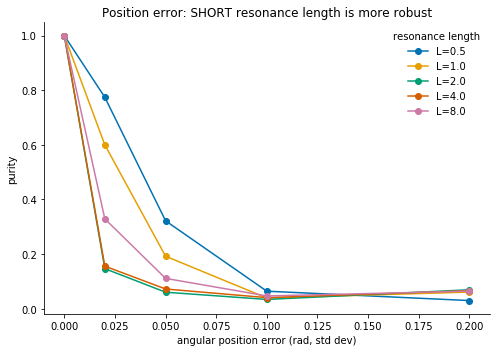

In [5]:
def ring_with_angle_jitter(n, radius, jitter, rng):
    return [
        (radius * np.cos(2 * np.pi * j / n + jitter * rng.standard_normal()),
         radius * np.sin(2 * np.pi * j / n + jitter * rng.standard_normal()), 0.0)
        for j in range(n)
    ]

N = 5
rho_test, baseline = 1.0, 2.3
t_test = T_CONV + baseline / C
jitters = [0.0, 0.02, 0.05, 0.1, 0.2]
Ls = [0.5, 1.0, 2.0, 4.0, 8.0]
n_seeds = 24

fig, ax = plt.subplots(figsize=(7, 5))
for color, L in zip(C_PALETTE, Ls):
    curve = []
    for j in jitters:
        vals = [purity(rho_test, t_test, ring_with_angle_jitter(N, R, j, np.random.default_rng(s)), L, N)
                for s in range(n_seeds)]
        curve.append(np.nanmean(vals))
    ax.plot(jitters, curve, marker="o", color=color, label=f"L={L}")
ax.set_xlabel("angular position error (rad, std dev)")
ax.set_ylabel("purity")
ax.set_title("Position error: SHORT resonance length is more robust")
ax.legend(frameon=False, title="resonance length")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("jitter_position.png", dpi=110)
plt.show()

Backwards from the classical interferometry intuition: the **shorter**-resonance sources hold onto the N-fold pattern better once positions are slightly wrong, not worse. I don't have a fully worked-out derivation for this one -- it's a robust, reproducible numerical result (checked across two independent random-seed sets), but the mechanism below is a plausible hypothesis, not a proof. Moving a source changes $r_j$, which shifts *both* the phase term $kr_j$ and the envelope's own argument (`behind = front - r`) together, correlated through the same displacement. A long-resonance source is close to a pure single-frequency tone -- spectrally narrow, close to "perfect" -- which may leave very little room to absorb a coupled position perturbation without some of it leaking into the wrong harmonics. A short-resonance source is already a broadband pulse (that's what a fast ringdown *is*, in Fourier terms), so the same absolute perturbation is a smaller *relative* disturbance. Worth flagging plainly: this explanation doesn't fully match what happens when timing error is decomposed into isolated channels below, so treat it as a lead, not a settled mechanism.

## Breaking it 2: source timing error -- and why it's not the same story

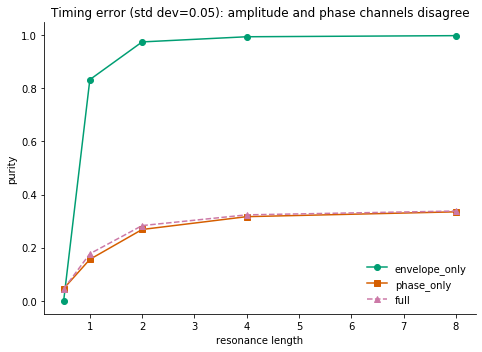

In [6]:
def ring_with_time_jitter(n, radius, jitter, rng):
    return [(radius * np.cos(2 * np.pi * j / n), radius * np.sin(2 * np.pi * j / n), jitter * rng.standard_normal())
            for j in range(n)]

def field_decoupled(X, Y, t, sources, resonance_length, mode):
    """mode splits a source's timing error into its two channels: the envelope (ringdown/causal
    gate -- an amplitude effect) and the oscillation phase (a phase effect), so each can be
    switched on independently. 'full' is the realistic case where both use the same jittered time."""
    Z = np.zeros_like(X)
    for sx, sy, t_jit in sources:
        r = np.sqrt((X - sx) ** 2 + (Y - sy) ** 2)
        t_env = t_jit if mode in ("full", "envelope_only") else 0.0
        t_phase = t_jit if mode in ("full", "phase_only") else 0.0
        front = C * (t - t_env)
        behind = front - r
        causal_gate = 0.5 * (1 + np.tanh(behind / EDGE_WIDTH))
        ringdown = np.exp(-np.clip(behind, 0, None) / resonance_length)
        amplitude = causal_gate * ringdown / np.sqrt(r + 0.3)
        Z += amplitude * np.cos(K * r - OMEGA * (t - t_phase))
    return Z

def purity_decoupled(rho, t, sources, resonance_length, N, mode):
    psi = np.linspace(0, 2 * np.pi, N_PSI, endpoint=False)
    X, Y = rho * np.cos(psi), rho * np.sin(psi)
    Z = field_decoupled(X, Y, t, sources, resonance_length, mode)
    power = np.abs(np.fft.rfft(Z)) ** 2
    ac_power = power[1:].sum()
    return power[N::N].sum() / ac_power if ac_power > 1e-30 else np.nan

time_jitter = 0.05
t_test2 = T_CONV + baseline / C + 0.3  # extra causal margin so a late-jittered source is still safely "on"

fig, ax = plt.subplots(figsize=(7, 5))
for mode, color, style in [("envelope_only", C_PALETTE[2], "-o"), ("phase_only", C_PALETTE[3], "-s"), ("full", C_PALETTE[4], "--^")]:
    vals = []
    for L in Ls:
        v = [purity_decoupled(rho_test, t_test2, ring_with_time_jitter(N, R, time_jitter, np.random.default_rng(s)), L, N, mode)
             for s in range(n_seeds)]
        vals.append(np.nanmean(v))
    ax.plot(Ls, vals, style, color=color, label=mode)
ax.set_xlabel("resonance length")
ax.set_ylabel("purity")
ax.set_title(f"Timing error (std dev={time_jitter}): amplitude and phase channels disagree")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("jitter_timing_decomposed.png", dpi=110)
plt.show()

The two channels behave very differently, but not quite as a clean mirror image:

- **Envelope-only** channel (amplitude mismatch from differing decay): purity climbs sharply toward 1 as resonance length grows -- this is exactly the classical coherence-length intuition, and it's the strongest effect in this whole notebook (near 0 at L=0.5, essentially 1 by L=4).
- **Phase-only** channel (the oscillation itself running off a slightly different clock per source): purity *also* improves with resonance length, but only modestly, and it plateaus far below the envelope channel's ceiling (roughly 0.04 to 0.3 over the same range, not 0 to 1). So longer resonance does help this channel a little -- just not much.
- **Full** (realistic) timing error tracks the phase-only curve almost exactly, because the phase channel is the bottleneck here: it never gets anywhere near as clean as the envelope channel does, so it dominates the combined result. The practical upshot is that a real synchronization error gets *some* benefit from longer resonance length, but nowhere near what the amplitude-channel story alone would promise.

This isn't the same effect as the position-jitter result just above, and I want to be honest that I haven't reconciled them into one mechanism: position error gets *worse* with longer resonance length, while the phase channel of timing error gets slightly *better*. Both are "phase-type" perturbations in a loose sense, but they clearly aren't interchangeable -- an open thread rather than a tidy unified story.

## Takeaways

- **Proven, not just observed:** N synchronized coherent sources arranged with exact $C_N$ symmetry produce an interference pattern whose angular Fourier content lives *only* at multiples of N -- for any resonance length, any causal-gate shape, any N (3 through 8 checked directly, purity = 1.000000 in every case). This follows from the rotational symmetry of the source layout alone, and the explicit Jacobi-Anger calculation recovers it via the same Bessel-function machinery used in circular antenna array theory.
- **A specific hypothesis, killed cleanly:** "resonance length limits how far the clean N-fold pattern extends" was the natural first guess and it is simply false when the layout is exact -- purity stayed at 1.000000 across two decades of resonance length and a 10x range of radius. Good reminder that a plausible-sounding coherence-length analogy from interferometry doesn't automatically transfer to a different setup; it took one cheap simulation to falsify.
- **What resonance length actually governs is robustness to imperfect placement, and it's not one clean story:**
  - Amplitude/decay mismatch from timing error (the envelope-only channel) behaves exactly like the classical coherence-length intuition: longer resonance protects against it, strongly.
  - The phase channel of timing error improves with resonance length too, but only modestly, and plateaus far below the amplitude channel's ceiling -- so it's the practical bottleneck for realistic (non-decomposed) timing error.
  - Pure position error is its own case, and it goes the *other* direction: shorter resonance length is more robust, not less. I have a plausible qualitative hypothesis for why (broadband sources have less spectrally "pure" content to disturb), but it doesn't fully reconcile with the timing-error phase channel's opposite-sign result, and I'm not claiming it does.
- **Practical upshot, stated carefully:** there is no single dial-turning rule ("more coherent is always better/worse"). Which direction helps depends on *which kind* of imperfection dominates in a given setup -- amplitude mismatch wants long resonance, position error wants short resonance, and this notebook doesn't yet explain why those disagree.
- **What this would need before actually submitting anywhere:** a real derivation (not just a plausibility argument) for the position-error trend, and an explanation for why it doesn't match the timing-error phase channel despite both looking like "phase-type" perturbations on the surface. That gap is the actual open question here, more than anything already answered.